In [1]:
import xarray as xr
ds_filtered = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/selected_filter_stations.nc")

In [6]:
import pandas as pd
df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/AAstation_GEV_6_msl.csv")

df['cluster'] = df.cluster_ensemble

# Get sorted unique remaining clusters
unique_clusters = sorted(df["cluster"].unique())

# Build mapping → start numbering from 1
cluster_map = {old: new for new, old in enumerate(unique_clusters, start=1)}

# Apply remapping
df["cluster"] = df["cluster"].map(cluster_map)

In [101]:
#df= df[df["cluster"] != 5]
# remap clusters to 0..k-1 in sorted order
#df["cluster"] = pd.Categorical(df["cluster"]).codes + 1

<Axes: >

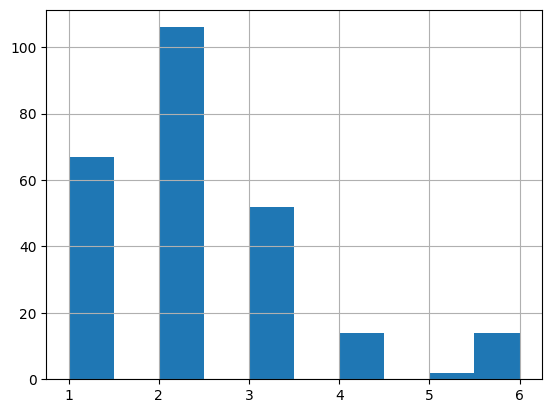

In [8]:
df.cluster.hist()

In [9]:
df = df[df["cluster"] != 5].copy()

unique_clusters = sorted(df["cluster"].unique())
mapping = {old: new for new, old in enumerate(unique_clusters, start=1)}
df["cluster"] = df["cluster"].map(mapping)

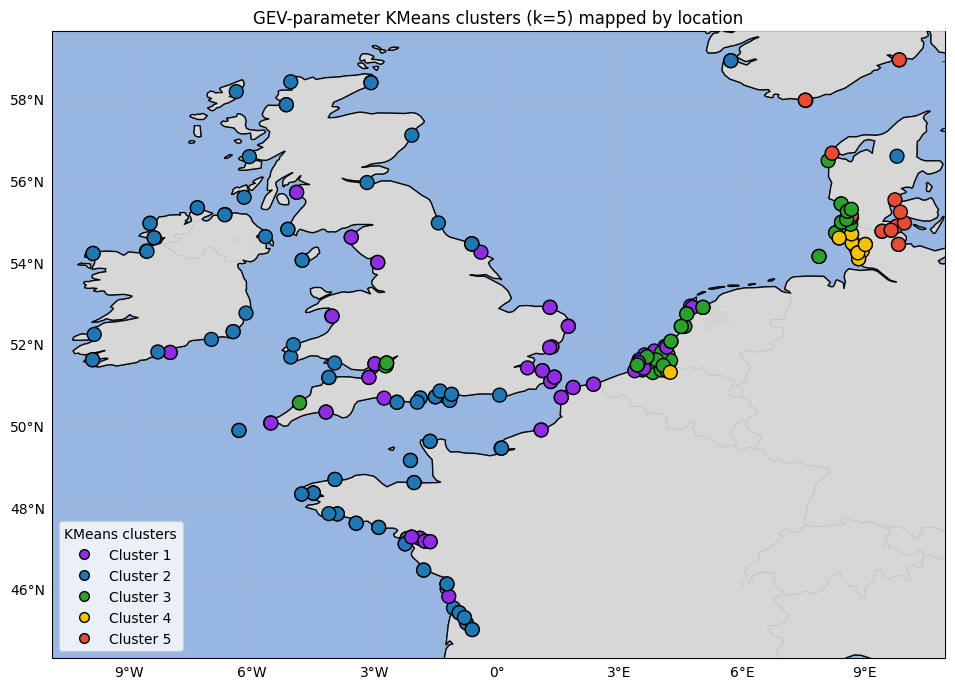

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
colors = [
    "#8E2DE2",  # purple
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#F2C300",  # yellow
    "#E64B35",  # orange-red
    "#e22cdc"
]


plotdf = df[["lon", "lat", "cluster"]].copy()

plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
#plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()
clusters = sorted(plotdf["cluster"].dropna().unique())
k = len(clusters)

cluster_to_idx = {(c): i for i, c in enumerate(clusters)}
plotdf["cluster_idx"] = plotdf["cluster"].map(cluster_to_idx)
colors = colors[:k]
cmap = mcolors.ListedColormap(colors)

norm = mcolors.BoundaryNorm(
    boundaries=np.arange(-0.5, k + 0.5, 1),
    ncolors=k
)
# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)

# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=7,
        markerfacecolor=cmap(i),
        markeredgecolor="k",
        label=f"Cluster {c}"   # ← original label
    )
    for i, c in enumerate(clusters)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"],
    plotdf["lat"],
    c=plotdf["cluster_idx"],   # ← IMPORTANT
    cmap=cmap,
    norm=norm,
    s=100,
    zorder=40,
    edgecolors="black",
    transform=ccrs.PlateCarree()
)

ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

# P-value: you want them to be drawn from the same distribution!!

GEV parameters are robust to record length and cluster-dependent, with shape parameters close to zero across most regimes.

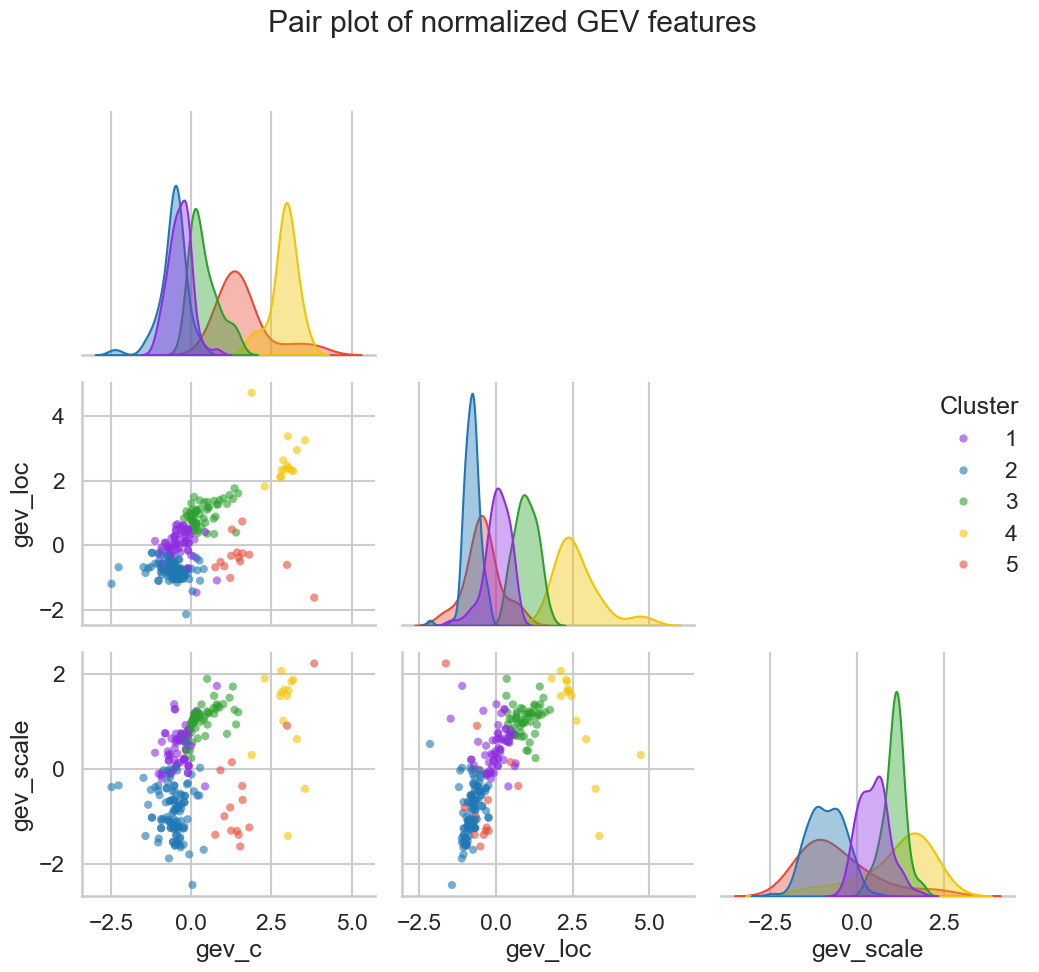

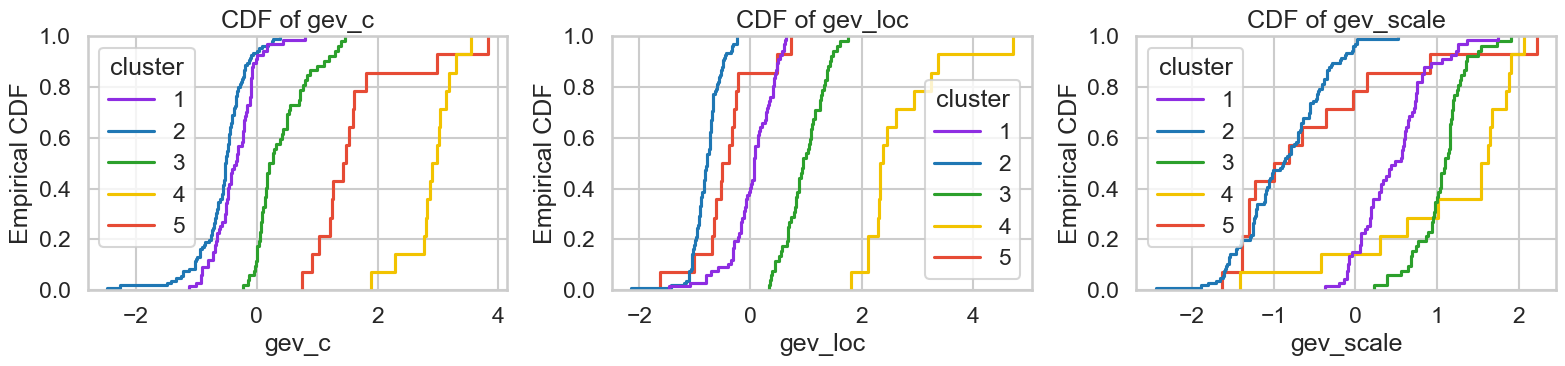

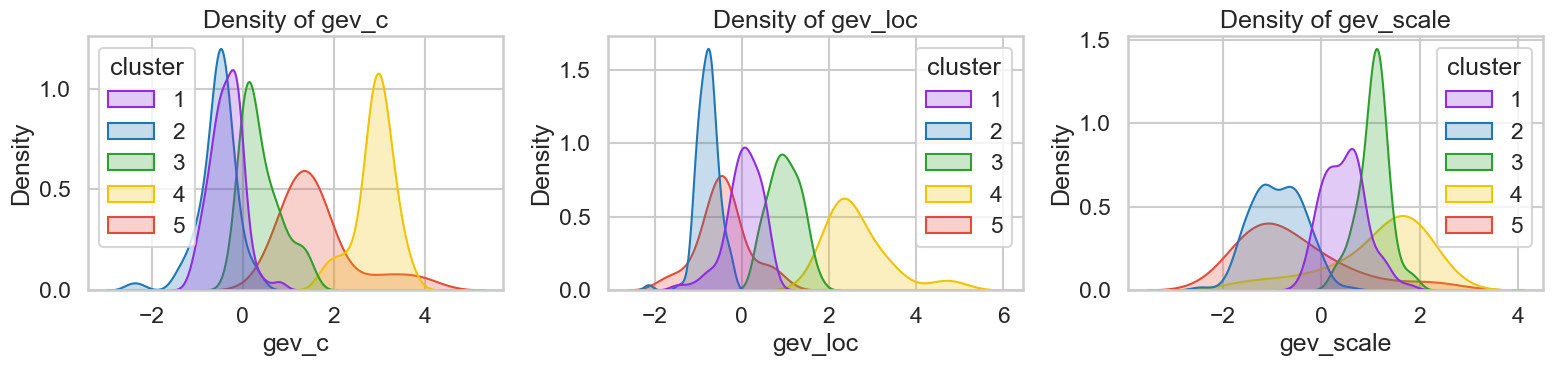

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["gev_c", "gev_loc", "gev_scale"]

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1) Prepare normalized features
# -----------------------------
cols = ["gev_c", "gev_loc", "gev_scale"]

plot_df = df.copy()

# if scale should be logged, do it here first
plot_df["gev_scale"] = pd.to_numeric(plot_df["gev_scale"], errors="coerce")
plot_df["gev_scale"] = np.where(plot_df["gev_scale"] > 0, np.log(plot_df["gev_scale"]), np.nan)

for c in ["gev_c", "gev_loc"]:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

plot_df = plot_df.dropna(subset=cols + ["cluster"]).copy()

# z-score normalization
scaler = StandardScaler()
plot_df[[f"{c}" for c in cols]] = scaler.fit_transform(plot_df[cols])

zcols = [f"{c}" for c in cols]

# -----------------------------
# 2) Pair plot on normalized vars
# -----------------------------
sns.set_style("whitegrid")
sns.set_context("talk")

g = sns.PairGrid(
    plot_df,
    vars=zcols,
    hue="cluster",
    palette=colors,
    corner=True,
    height=3.2
)

g.map_lower(
    sns.scatterplot,
    s=35,
    alpha=0.6,
    edgecolor="none"
)

g.map_diag(
    sns.kdeplot,
    fill=True,
    alpha=0.4,
    common_norm=False  # each cluster density integrates to 1
)

g.add_legend(title="Cluster")
g.fig.suptitle("Pair plot of normalized GEV features", y=1.02)
g.fig.tight_layout()
plt.show()

# -----------------------------
# 3) CDFs side by side by feature
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, c in zip(axes, zcols):
    sns.ecdfplot(
        data=plot_df,
        x=c,
        hue="cluster",
        ax=ax,
        palette=colors
    )
    ax.set_title(f"CDF of {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Empirical CDF")

plt.tight_layout()
plt.show()

# -----------------------------
# 4) Density plots side by side
#    normalized within cluster
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, c in zip(axes, zcols):
    sns.kdeplot(
        data=plot_df,
        x=c,
        hue="cluster",
       # fill=False,
        palette=colors,
        common_norm=False,  # each cluster curve area = 1
        ax=ax,
        fill=True
        
    )
    ax.set_title(f"Density of {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import silhouette_score

X = df[["gev_c", "gev_loc", "gev_scale"]].values
labels = df["cluster"].values

score = silhouette_score(X, labels)

print("Silhouette score:", score)

Silhouette score: 0.4182861872529077


In [13]:
from sklearn.decomposition import PCA

X = df[["gev_c","gev_loc","gev_scale"]]

pca = PCA(n_components=2)
Xp = pca.fit_transform(X)

plt.figure(figsize=(6,5))

for cl in sorted(df["cluster"].unique()):
    print(idx)
    idx = df["cluster"] == (cl-1)
    colour = colors[cl-1]
    plt.scatter(
        Xp[idx,0],
        Xp[idx,1],
        label=f"C{cl}",
        cmap=colour,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Cluster separation in parameter space")
plt.show()

NameError: name 'idx' is not defined

<Figure size 600x500 with 0 Axes>

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = df[["gev_c","gev_loc","gev_scale"]]
y = df["cluster"]

rf = RandomForestClassifier(n_estimators=500, random_state=0)

scores = cross_val_score(rf, X, y, cv=5)

print("Mean accuracy:", scores.mean())

Mean accuracy: 0.960392156862745


In [15]:
ds=ds_filtered

In [162]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st

# -----------------------------
# config
# -----------------------------
TARGET_VAR = "residual"
N_STATIONS = 295
RESAMPLE_RULE = "2M"     # 2-month block maxima
STEP_YEARS = 10
MIN_VALID_POINTS = 10
MIN_BLOCKS = 5

# -----------------------------
# choose variable if needed
# -----------------------------
if TARGET_VAR not in ds.data_vars:
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}'")
            break
    else:
        raise ValueError("No numeric data variable found.")

# -----------------------------
# helpers
# -----------------------------
def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

def _record_length_years(time_values):
    t = pd.to_datetime(np.asarray(time_values))
    t = t[~pd.isnull(t)]
    if len(t) < 2:
        return np.nan
    return (t.max() - t.min()) / np.timedelta64(1, "D") / 365.25

stations = np.array(ds["station"].values)[:N_STATIONS]

rows = []

for s in stations:
    da = ds[TARGET_VAR].sel(station=s)

    try:
        tdim = _time_dim(da)
    except Exception:
        continue

    da = da.where(np.isfinite(da), drop=True)

    if da.size < MIN_VALID_POINTS:
        continue

    try:
        times = pd.to_datetime(da[tdim].values)
        t0 = pd.Timestamp(times.min())
        total_years = _record_length_years(times)
    except Exception:
        continue

    if not np.isfinite(total_years) or total_years < STEP_YEARS:
        continue

    # fit progressively longer prefixes of the record
    max_step = int(np.floor(total_years / STEP_YEARS)) * STEP_YEARS

    for yrs in range(STEP_YEARS, max_step + 1, STEP_YEARS):
        t1 = t0 + pd.DateOffset(years=yrs)

        try:
            da_sub = da.sel({tdim: slice(t0, t1)})
        except Exception:
            continue

        da_sub = da_sub.where(np.isfinite(da_sub), drop=True)

        if da_sub.size < MIN_VALID_POINTS:
            continue

        try:
            da_max = da_sub.resample({tdim: RESAMPLE_RULE}).max()
        except Exception:
            continue

        x = np.asarray(da_max.values)
        x = x[np.isfinite(x)]

        if x.size < MIN_BLOCKS:
            continue

        try:
            c, loc, scale = st.genextreme.fit(x)
        except Exception:
            continue

        rows.append({
            "station": int(s),
            "years_used": int(yrs),
            "gev_c": c,
            "gev_loc": loc,
            "gev_scale": scale,
            "n_blocks": int(x.size),
            "total_years": float(total_years),
        })

df_stab = pd.DataFrame(rows)

if df_stab.empty:
    raise RuntimeError("No station stability fits were produced.")

print(df_stab.head())
print(f"Stations contributing: {df_stab['station'].nunique()}")

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

   station  years_used     gev_c   gev_loc  gev_scale  n_blocks  total_years
0        1          10 -0.000114  0.469840   0.151726        61    66.254962
1        1          20 -0.006923  0.442511   0.144408       121    66.254962
2        1          30  0.049929  0.419357   0.159566       181    66.254962
3        1          40 -0.012319  0.411075   0.153329       241    66.254962
4        1          50 -0.005090  0.405223   0.152610       301    66.254962
Stations contributing: 246


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [185]:
df_stab.to_csv("/Users/lb962/Documents/GitHub/ESL_stats/data/stability_characteristics/df_stabc5msl.csv")

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_29459/725863650.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


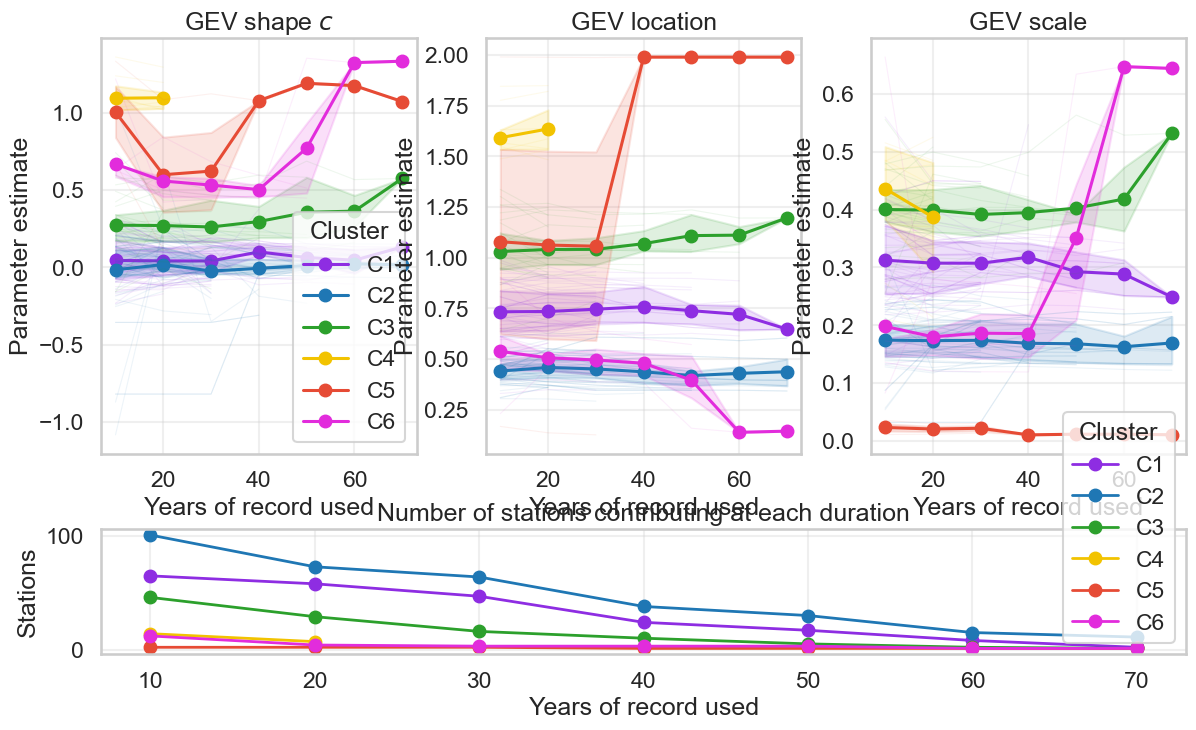

In [177]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# load and remap clusters
# -------------------------
#df_cluster = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
#df_cluster = df_cluster[~df_cluster["cluster"].isin([0, 5])].copy()
df_cluster= df
unique_clusters = sorted(df_cluster["cluster"].unique())
cluster_map = {old: new for new, old in enumerate(unique_clusters, start=1)}
df_cluster["cluster"] = df_cluster["cluster"].map(cluster_map)

# keep only needed columns
df_cluster = df_cluster[["station", "cluster"]].drop_duplicates()

# make sure station dtype matches
df_stab["station"] = df_stab["station"].astype(int)
df_cluster["station"] = df_cluster["station"].astype(int)

# -------------------------
# merge cluster info onto stability table
# -------------------------
df_stab_cl = df_stab.merge(df_cluster, on="station", how="inner")

if df_stab_cl.empty:
    raise RuntimeError("No overlap between df_stab stations and cluster table.")

# -------------------------
# cluster-wise summaries
# -------------------------
summary_cl = (
    df_stab_cl
    .groupby(["cluster", "years_used"])
    .agg(
        gev_c_mean=("gev_c", "mean"),
        gev_c_q25=("gev_c", lambda x: x.quantile(0.25)),
        gev_c_q75=("gev_c", lambda x: x.quantile(0.75)),

        gev_loc_mean=("gev_loc", "mean"),
        gev_loc_q25=("gev_loc", lambda x: x.quantile(0.25)),
        gev_loc_q75=("gev_loc", lambda x: x.quantile(0.75)),

        gev_scale_mean=("gev_scale", "mean"),
        gev_scale_q25=("gev_scale", lambda x: x.quantile(0.25)),
        gev_scale_q75=("gev_scale", lambda x: x.quantile(0.75)),

        n_stations=("station", "nunique"),
    )
    .reset_index()
)

# -------------------------
# plot
# -------------------------
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[4, 1.2], hspace=0.28, wspace=0.22)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_n = fig.add_subplot(gs[1, :])

specs = [
    ("gev_c", "gev_c_mean", "gev_c_q25", "gev_c_q75", "GEV shape $c$"),
    ("gev_loc", "gev_loc_mean", "gev_loc_q25", "gev_loc_q75", "GEV location"),
    ("gev_scale", "gev_scale_mean", "gev_scale_q25", "gev_scale_q75", "GEV scale"),
]

import matplotlib.colors as mcolors
import numpy as np

# Ensure clusters are integers and sorted
clusters = np.sort(df_stab_cl["cluster"].unique())
n_clusters = len(clusters)

colors = colors
cmap = mcolors.ListedColormap(colors)
bounds = np.arange(n_clusters + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create cluster → color mapping
cluster_colours = {cl: colors[i] for i, cl in enumerate(clusters)}
clusters = sorted(df_stab_cl["cluster"].dropna().unique())

for ax, (col, mean_col, q25_col, q75_col, title) in zip(axes, specs):

    for cl in clusters:
        colour = cluster_colours[cl]
        gcl = df_stab_cl[df_stab_cl["cluster"] == cl].copy()
        scl = summary_cl[summary_cl["cluster"] == cl].copy()

        # faint station trajectories within this cluster
        for station_id, g in gcl.groupby("station"):
            g = g.sort_values("years_used")
            ax.plot(
                g["years_used"],
                g[col],
                alpha=0.08,
                color=colour,
                linewidth=0.8
            )

        # IQR envelope for this cluster
        ax.fill_between(
            scl["years_used"],
            scl[q25_col],
            scl[q75_col],
            color=colour,
            alpha=0.15
        )

        # mean trajectory for this cluster
        ax.plot(
            scl["years_used"],
            scl[mean_col],
            marker="o",
            color=colour,
            linewidth=2.2,
            label=f"C{cl}"
        )

    ax.set_title(title)
    ax.set_xlabel("Years of record used")
    ax.set_ylabel("Parameter estimate")
    ax.grid(alpha=0.3)

axes[0].legend(title="Cluster", loc="best")

# number of stations per cluster
for cl in clusters:
    colour = cluster_colours[cl]
    scl = summary_cl[summary_cl["cluster"] == cl].copy()
    ax_n.plot(
        scl["years_used"],
        scl["n_stations"],
        marker="o",
        linewidth=2.0,
        color=colour,
        label=f"C{cl}"
    )

ax_n.set_xlabel("Years of record used")
ax_n.set_ylabel("Stations")
ax_n.legend(title="Cluster", loc="best")
ax_n.set_title("Number of stations contributing at each duration")
ax_n.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# clusters are very distinct.

In [163]:
summary = (
    df_stab
    .groupby("years_used")
    .agg(
        gev_c_median=("gev_c", "median"),
        gev_c_q25=("gev_c", lambda x: x.quantile(0.25)),
        gev_c_q75=("gev_c", lambda x: x.quantile(0.75)),

        gev_loc_median=("gev_loc", "median"),
        gev_loc_q25=("gev_loc", lambda x: x.quantile(0.25)),
        gev_loc_q75=("gev_loc", lambda x: x.quantile(0.75)),

        gev_scale_median=("gev_scale", "median"),
        gev_scale_q25=("gev_scale", lambda x: x.quantile(0.25)),
        gev_scale_q75=("gev_scale", lambda x: x.quantile(0.75)),

        n_stations=("station", "nunique"),
    )
    .reset_index()
)

print(summary)

   years_used  gev_c_median  gev_c_q25  gev_c_q75  gev_loc_median  \
0          10      0.109097  -0.030625   0.263537        0.611656   
1          20      0.097253  -0.008284   0.188143        0.616119   
2          30      0.044352  -0.032781   0.145650        0.544488   
3          40      0.085243  -0.014752   0.154649        0.532055   
4          50      0.045032  -0.005118   0.129517        0.506920   
5          60      0.037396  -0.002199   0.123203        0.505291   
6          70      0.029222   0.004563   0.137305        0.447712   

   gev_loc_q25  gev_loc_q75  gev_scale_median  gev_scale_q25  gev_scale_q75  \
0     0.444328     0.899604          0.243559       0.174053       0.377560   
1     0.465726     0.898308          0.248518       0.169371       0.346474   
2     0.429983     0.802666          0.234059       0.165494       0.322644   
3     0.413968     0.846351          0.215641       0.154098       0.326607   
4     0.398985     0.730830          0.205677       

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_29459/4124363502.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


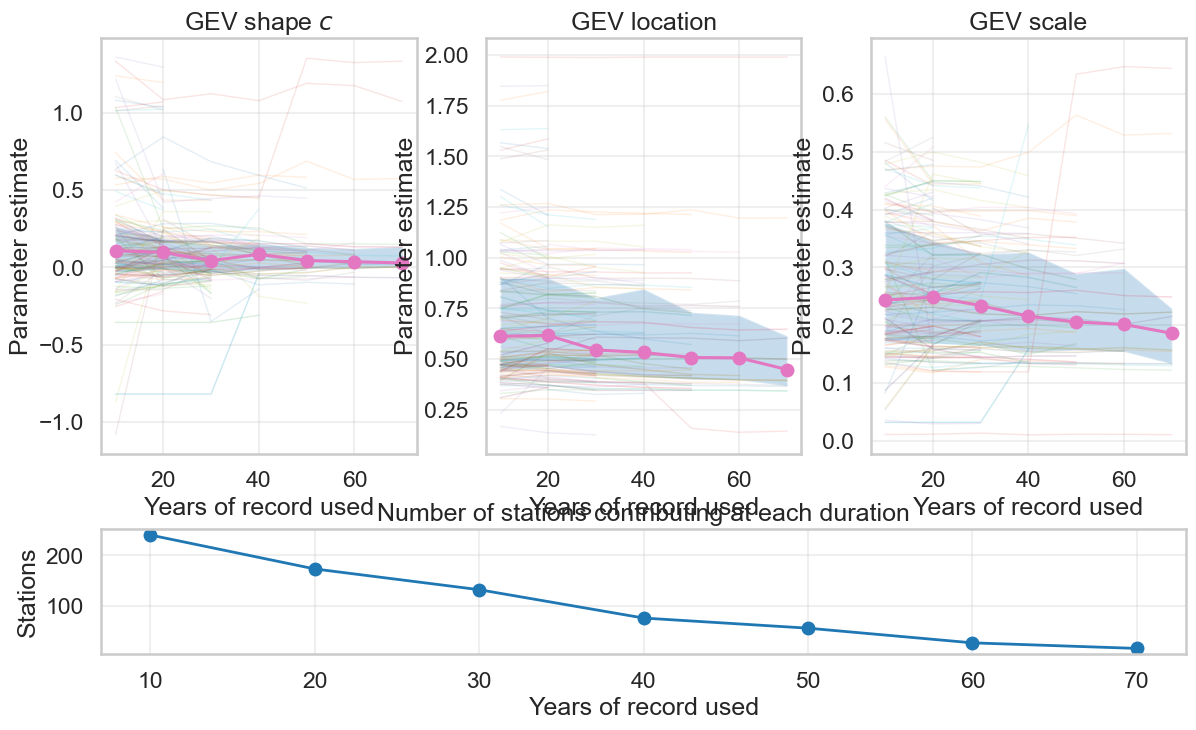

In [164]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[4, 1.2], hspace=0.28, wspace=0.22)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_n = fig.add_subplot(gs[1, :])

specs = [
    ("gev_c", "gev_c_median", "gev_c_q25", "gev_c_q75", "GEV shape $c$"),
    ("gev_loc", "gev_loc_median", "gev_loc_q25", "gev_loc_q75", "GEV location"),
    ("gev_scale", "gev_scale_median", "gev_scale_q25", "gev_scale_q75", "GEV scale"),
]

for ax, (col, med, q25, q75, title) in zip(axes, specs):

    # faint individual station trajectories
    for station_id, g in df_stab.groupby("station"):
        g = g.sort_values("years_used")
        ax.plot(
            g["years_used"],
            g[col],
            linewidth=1.0,
            alpha=0.12
        )

    # IQR envelope
    ax.fill_between(
        summary["years_used"],
        summary[q25],
        summary[q75],
        alpha=0.25
    )

    # ensemble median
    ax.plot(
        summary["years_used"],
        summary[med],
        marker="o",
        linewidth=2.2
    )

    ax.set_title(title)
    ax.set_xlabel("Years of record used")
    ax.set_ylabel("Parameter estimate")
    ax.grid(alpha=0.3)

# number of stations panel
ax_n.plot(
    summary["years_used"],
    summary["n_stations"],
    marker="o",
    linewidth=2
)
ax_n.set_xlabel("Years of record used")
ax_n.set_ylabel("Stations")
ax_n.set_title("Number of stations contributing at each duration")
ax_n.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [167]:
for ax in axes + [ax_n]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# optional panel labels
for label, ax in zip(["a", "b", "c"], axes):
    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12, fontweight="bold"
    )

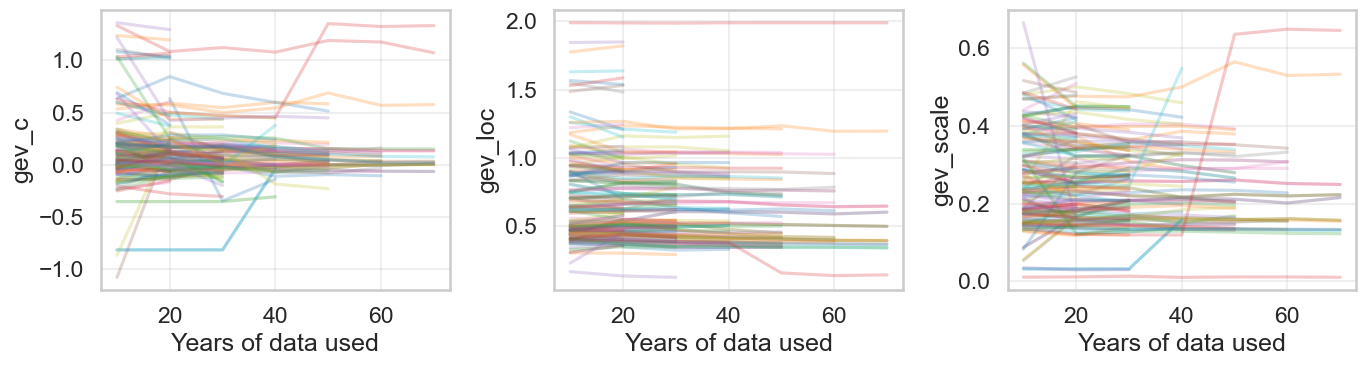

In [169]:
fig, axes = plt.subplots(1,3, figsize=(14,4))

params = ["gev_c","gev_loc","gev_scale"]

for i,p in enumerate(params):

    for s, g in df_stab.groupby("station"):
        axes[i].plot(g["years_used"], g[p], alpha=0.25)

    axes[i].set_xlabel("Years of data used")
    axes[i].set_ylabel(p)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# dataframe with common predictors

In [17]:
df_cluster=df[["cluster", "station"]]

In [18]:
cluster_da = (
    df_cluster
    .set_index("station")["cluster"]
    .to_xarray()
)

# add to dataset
ds_filtered = ds_filtered.assign(cluster=cluster_da)

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_8713/2383188857.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data, labels=labels, patch_artist=True)


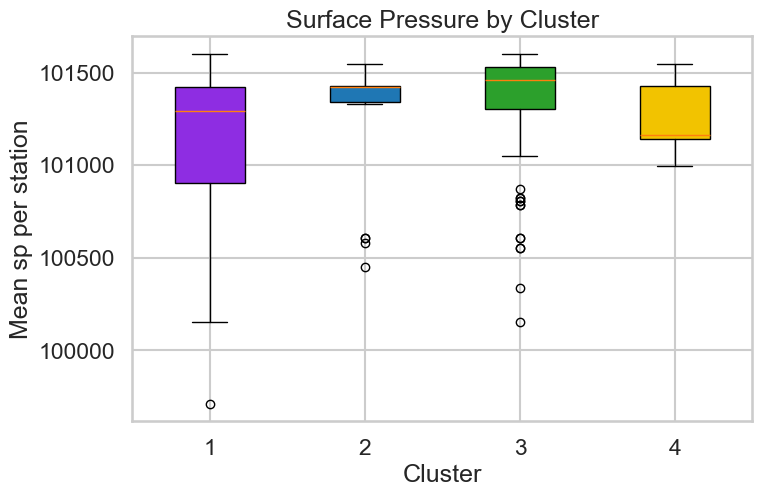

In [19]:
import matplotlib.pyplot as plt
# mean per station (fast, lazy if dask-backed)
sp_station = ds_filtered.sp.mean(dim="valid_time")
grouped = sp_station.groupby(ds_filtered.cluster)

data = [group.values for _, group in grouped]
labels = [int(c) for c, _ in grouped]
plt.figure(figsize=(8, 5))
bplot = plt.boxplot(data, labels=labels, patch_artist=True)

plt.xlabel("Cluster")
plt.ylabel("Mean sp per station")
plt.title("Surface Pressure by Cluster")
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_8713/1929496729.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data, labels=labels, patch_artist=True)


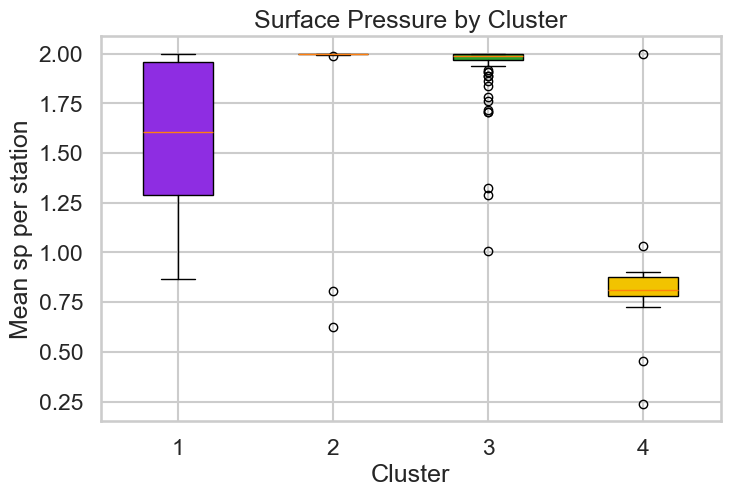

In [21]:
import matplotlib.pyplot as plt
# mean per station (fast, lazy if dask-backed)
sp_station = ds_filtered.residual.max(dim="valid_time")
grouped = sp_station.groupby(ds_filtered.cluster)

data = [group.values for _, group in grouped]
labels = [int(c) for c, _ in grouped]
plt.figure(figsize=(8, 5))
bplot = plt.boxplot(data, labels=labels, patch_artist=True)

plt.xlabel("Cluster")
plt.ylabel("Mean sp per station")
plt.title("Surface Pressure by Cluster")
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_8713/2782382535.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data, labels=labels, patch_artist=True)


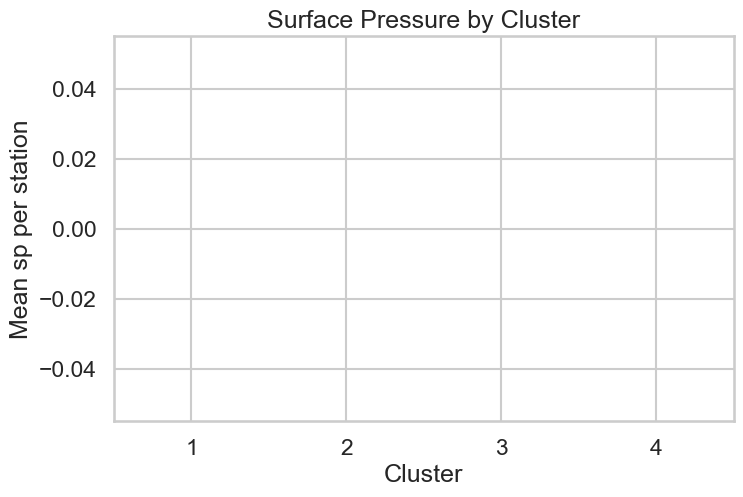

In [26]:
import matplotlib.pyplot as plt
# mean per station (fast, lazy if dask-backed)
sp_station = ds_filtered.mwd.max(dim="valid_time")
grouped = sp_station.groupby(ds_filtered.cluster)

data = [group.values for _, group in grouped]
labels = [int(c) for c, _ in grouped]
plt.figure(figsize=(8, 5))
bplot = plt.boxplot(data, labels=labels, patch_artist=True)

plt.xlabel("Cluster")
plt.ylabel("Mean sp per station")
plt.title("Surface Pressure by Cluster")
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_8713/246152850.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data, labels=labels, patch_artist=True)


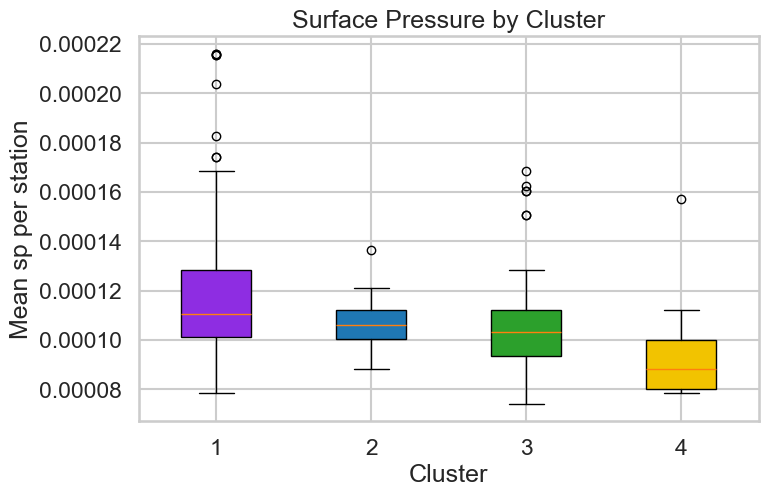

In [23]:
import matplotlib.pyplot as plt
# mean per station (fast, lazy if dask-backed)
sp_station = ds_filtered.tp.mean(dim="valid_time")
grouped = sp_station.groupby(ds_filtered.cluster)

data = [group.values for _, group in grouped]
labels = [int(c) for c, _ in grouped]
plt.figure(figsize=(8, 5))
bplot = plt.boxplot(data, labels=labels, patch_artist=True)

plt.xlabel("Cluster")
plt.ylabel("Mean sp per station")
plt.title("Surface Pressure by Cluster")
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
# mean per station (fast, lazy if dask-backed)
sp_station = ds_filtered..mean(dim="valid_time")
grouped = sp_station.groupby(ds_filtered.cluster)

data = [group.values for _, group in grouped]
labels = [int(c) for c, _ in grouped]
plt.figure(figsize=(8, 5))
bplot = plt.boxplot(data, labels=labels, patch_artist=True)

plt.xlabel("Cluster")
plt.ylabel("Mean sp per station")
plt.title("Surface Pressure by Cluster")
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()